## **Exercise 03 : Bar charts**

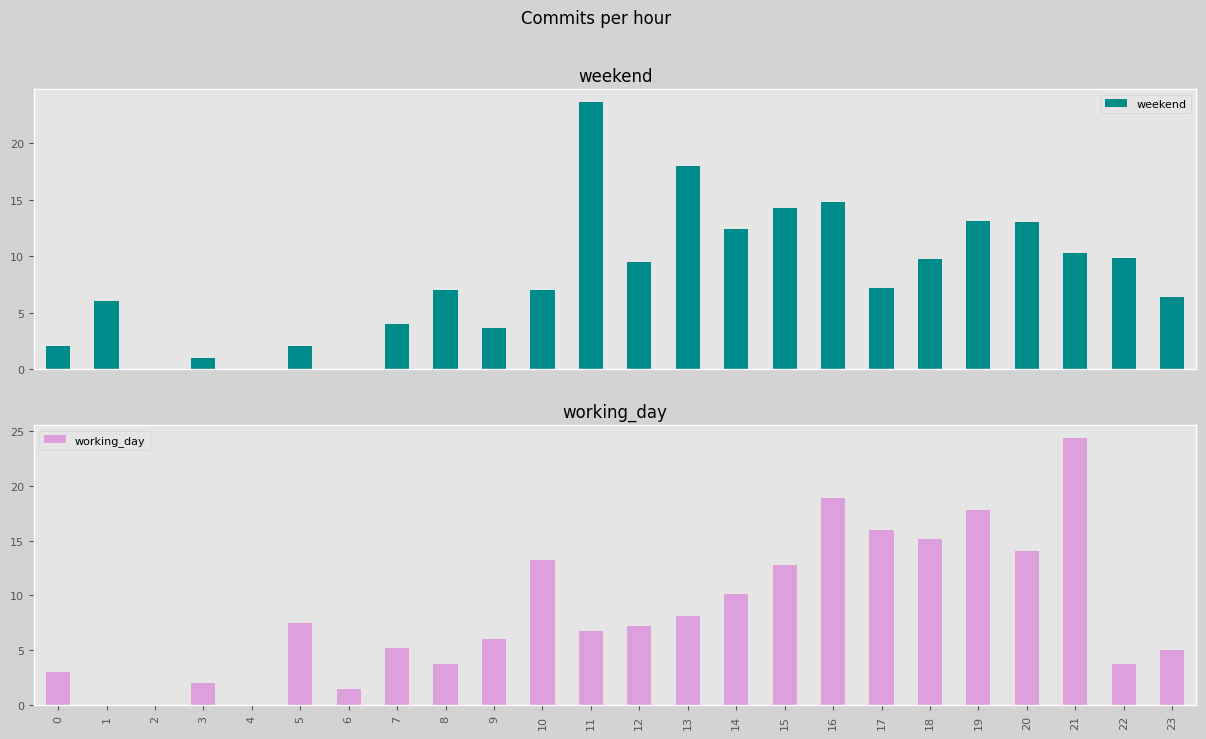

In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

connection = sqlite3.connect('../data/checking-logs.sqlite')
commits = pd.read_sql('select timestamp as commits from checker where uid like "%user_%"', connection)
commits[['date', 'hour']] = commits['commits'].apply(lambda x: pd.Series([i for i in x.split()]))

days = pd.date_range(commits['date'].min(), commits['date'].max())
working = days[days.dayofweek < 5]
week_end = days[days.dayofweek >= 5]

commits['date'] = pd.to_datetime(commits['date'])
commits['hour'] = pd.to_datetime(commits['hour'], format="%H:%M:%S.%f").dt.hour
working_day = commits.loc[commits['date'].isin(working)]
weekend = commits.loc[commits['date'].isin(week_end)]

out = []
for x in [weekend, working_day]:
    x = x.groupby(['date',], observed=False)['hour'].value_counts()
    x = x.to_frame().unstack()
    x.columns = x.columns.droplevel(0)
    x = x.describe().loc['mean']
    missing = set(range(0, 24)) - set(x.index)
    x = x.add(pd.Series([0.0 for x in range(len(missing))], index=missing), fill_value=0)
    out.append(x)

plt.style.use('ggplot')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8))
fig.suptitle("Commits per hour", fontsize=12)

out[0].plot.bar(ax = ax1,subplots=True, fontsize=8, label='weekend', color='darkcyan')
ax1.set_title("weekend",fontsize=12)
ax1.legend(prop={'size': 8})
ax1.set_xticks([])
ax1.xaxis.grid(False)
ax1.yaxis.grid(False)

out[1].plot.bar(ax = ax2,subplots=True, fontsize=8, label='working_day', color='plum')
ax2.set_title("working_day",fontsize=12)
ax2.legend(prop={'size': 8})
ax2.xaxis.grid(False)
ax2.yaxis.grid(False)

fig.patch.set_facecolor('lightgrey')
plt.show()

In [2]:
connection.close()

In [3]:
# “Is the dynamic different on working days and weekends?”, for the answer
# include the hour when the number of commits is the largest during working days
# and the hour when it is the largest during the weekend.
weekend = out[0].loc[out[0] == out[0].max()]
working_day = out[1].loc[out[1] == out[1].max()]
print(f'Is the dynamic different on working days and weekends: \n\n\
1. Q: The hour when the number of commits is the largest during working days? \n\
1. A: {int(working_day.reset_index()["index"][0])} \n\n\
2. Q: The hour when it is the largest during the weekend?\n\
2. A: {int(weekend.reset_index()["index"][0])}.')

Is the dynamic different on working days and weekends: 

1. Q: The hour when the number of commits is the largest during working days? 
1. A: 21 

2. Q: The hour when it is the largest during the weekend?
2. A: 11.
